# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (scores.mean(), scores.std())

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [7]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C' : [0.1, 1, 10, 100],
    'svm__gamma' : ['scale', 0.01, 0.001],
    'svm__kernel' : ['rbf', 'linear'],
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(estimator=svm_pipe, param_grid=svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [9]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

df = pd.DataFrame(svm_grid_search.cv_results_)
top_config = df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score')
top_config.head(10)

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators' : randint(50, 500),
    'max_depth' : [None] + list(randint(2, 20).rvs(10)),                
    'min_samples_split' : randint(2, 20),        
    'max_features' : ['sqrt', 'log2', 0.5],
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

base_rf = RandomForestClassifier(random_state=42)

rf_random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=rf_param_dist,
    n_iter=50, 
    cv=5,                   
    scoring='f1_macro',
    random_state=42,        
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': np.int64(15), 'max_features': 0.5, 'min_samples_split': 3, 'n_estimators': 393}
Лучший CV F1: 0.9576


Возможно небольшой прирост в результате у RandomForest classifier вызван относительно небольшим числом подбора параметров (50)

## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [13]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_svm = svm_grid_search.predict(X_test)
print("\nSVM Grid Search on Test Set")
print(classification_report(y_test, y_pred_svm))
svm_test_f1 = f1_score(y_test, y_pred_svm, average='macro')

# 2. Предсказания для RF
y_pred_rf = rf_random_search.predict(X_test)
print("\nRF Random Search on Test Set")
print(classification_report(y_test, y_pred_rf))
rf_test_f1 = f1_score(y_test, y_pred_rf, average='macro')

# Сводная таблица (можно оформить вручную или через print)
print(f"{'Модель':<20} | {'CV F1 (mean)':<12} | {'Test F1':<10}")
print("-" * 45)
print(f"{'SVM Baseline':<20} | {'0.9694':<12} | {'N/A':<10}") 
print(f"{'SVM Grid Search':<20} | {'0.9786':<12} | {svm_test_f1:<10.4f}")
print(f"{'RF Baseline':<20} | {'0.9504':<12} | {'N/A':<10}")
print(f"{'RF Random Search':<20} | {'0.9576':<12} | {rf_test_f1:<10.4f}")

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |


SVM Grid Search on Test Set
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


RF Random Search on Test Set
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Модель               | CV F1 (mean) | Test F1   
---------------------------------------------
SVM Baseline         | 0.9694       | N/A       
SVM Grid Search      | 0.9786       | 0.9812    
RF Baseline          | 0.9504       | N/A       
RF Random Search     | 0.9576       | 0.9526 

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

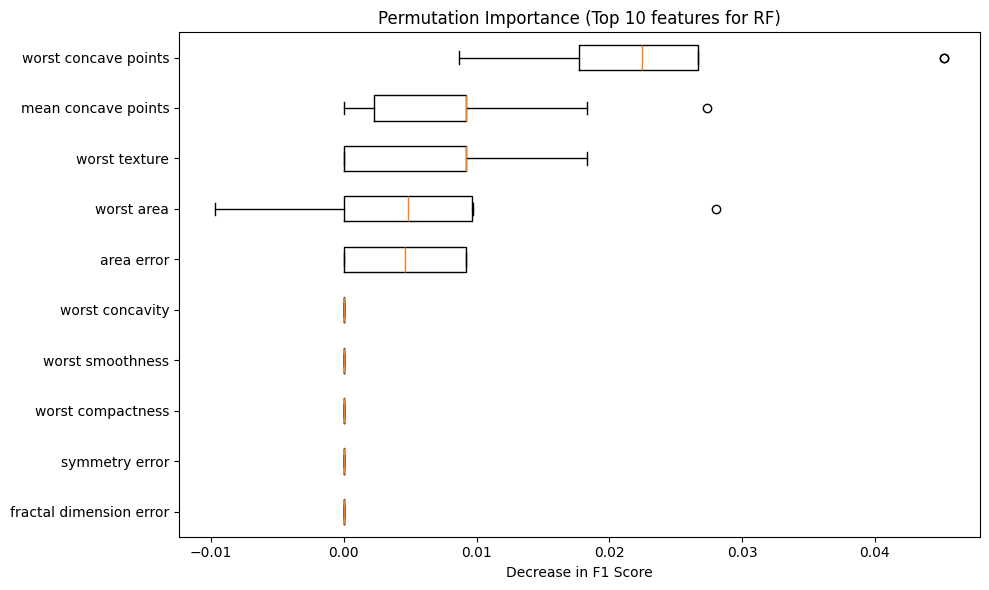

In [17]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

pi_result = permutation_importance(
    best_rf, 
    X_test, 
    y_test, 
    n_repeats=10,
    random_state=42, 
    scoring='f1_macro'
)

sorted_idx = pi_result.importances_mean.argsort()
# Построим bar plot топ-10 признаков
top_n = 10
top_idx = sorted_idx[-top_n:]


plt.figure(figsize=(10, 6))
plt.boxplot(pi_result.importances[top_idx].T, vert=False, labels=X_test.columns[top_idx])
plt.title("Permutation Importance (Top 10 features for RF)")
plt.xlabel("Decrease in F1 Score")
plt.tight_layout()
plt.show()

График показывает, насколько упадет F1-score, если мы перемешаем значения признака.
Топ-3 самых важных признака для RF:
1) worst concave points — самый важный.
2) mean concave points.
3) worst texture.
Признаки worst concavity, worst smoothness и другие имеют важность около нуля или даже отрицательную (выбросы влево). Отрицательная важность в PI означает, что случайное перемешивание этого признака случайно улучшило метрику на некоторых фолдах, то есть признак, скорее всего, является шумом или сильно коррелирует с другими признаками.

Топ-5 признаков по Встроенной важности (Feature Importances)
worst perimeter                : 0.2184
worst concave points           : 0.1853
worst area                     : 0.1465
worst radius                   : 0.1398
mean concave points            : 0.1171

Топ-5 признаков по Permutation Importance (PI)
worst concave points           : 0.0250
mean concave points            : 0.0092
worst texture                  : 0.0064
worst area                     : 0.0057
area error                     : 0.0046


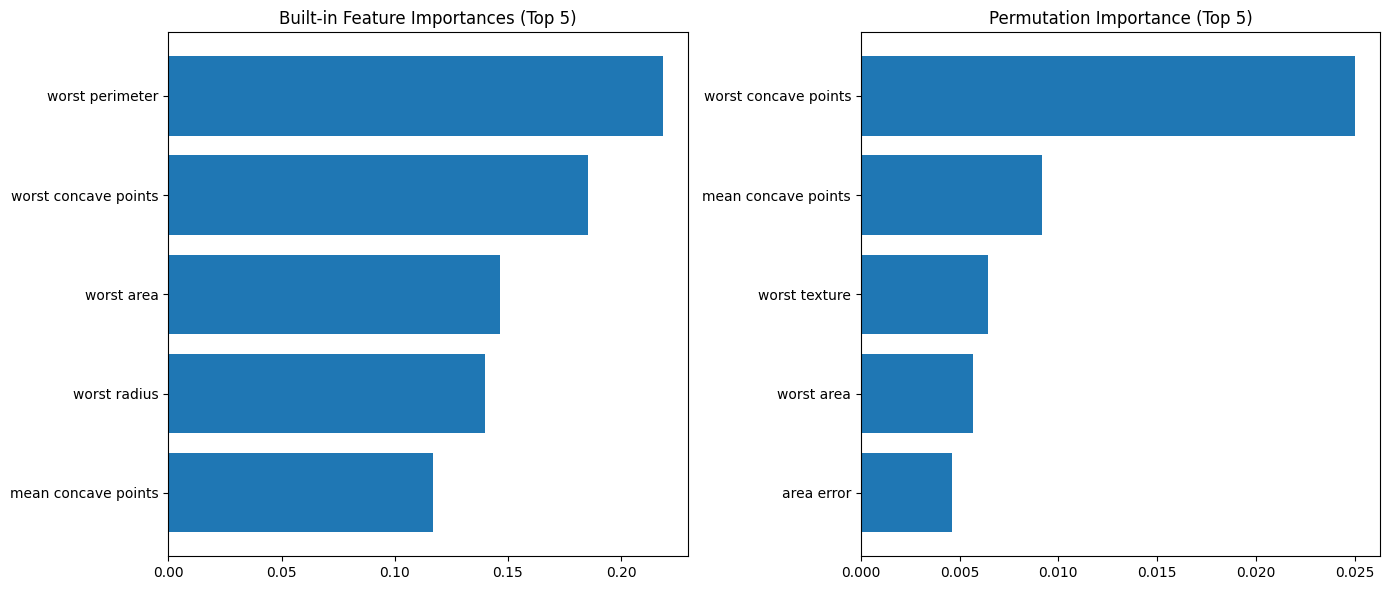

In [18]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

rf_importances = best_rf.feature_importances_

sorted_idx_builtin = rf_importances.argsort()[::-1] 

top5_builtin_idx = sorted_idx_builtin[:5]
top5_builtin_names = X_test.columns[top5_builtin_idx]
top5_builtin_values = rf_importances[top5_builtin_idx]

print("Топ-5 признаков по Встроенной важности (Feature Importances)")
for name, val in zip(top5_builtin_names, top5_builtin_values):
    print(f"{name:30s} : {val:.4f}")

sorted_idx_pi = pi_result.importances_mean.argsort()[::-1]
top5_pi_idx = sorted_idx_pi[:5]
top5_pi_names = X_test.columns[top5_pi_idx]
top5_pi_values = pi_result.importances_mean[top5_pi_idx]

print("\nТоп-5 признаков по Permutation Importance (PI)")
for name, val in zip(top5_pi_names, top5_pi_values):
    print(f"{name:30s} : {val:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(range(len(top5_builtin_names)), top5_builtin_values)
axes[0].set_yticks(range(len(top5_builtin_names)))
axes[0].set_yticklabels(top5_builtin_names)
axes[0].set_title("Built-in Feature Importances (Top 5)")
axes[0].invert_yaxis()

axes[1].barh(range(len(top5_pi_names)), top5_pi_values)
axes[1].set_yticks(range(len(top5_pi_names)))
axes[1].set_yticklabels(top5_pi_names)
axes[1].set_title("Permutation Importance (Top 5)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

Built-in считает на X_train, PI на X_test; Built-in деревья могут случайно выбрать один из коррелирующих признаков для разбиения и присвоить ему всю важность, обделив другие.
В PI, если перемешать один коррелирующий признак, модель может использовать другой похожий признак, поэтому падение метрики будет небольшим.

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

Топ-3 признака для PDP (по PI): ['worst texture', 'mean concave points', 'worst concave points']


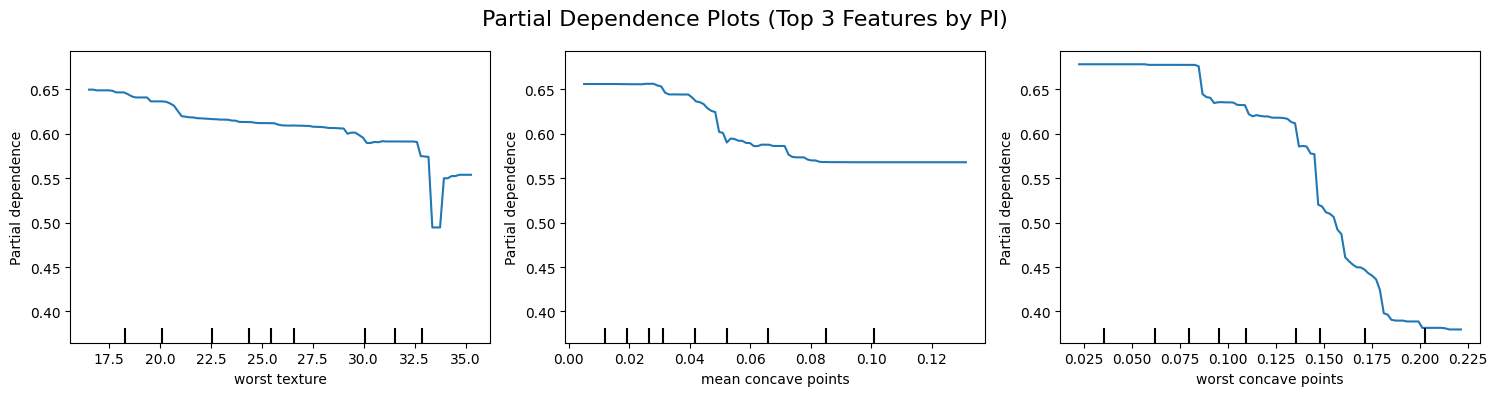

In [19]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
sorted_idx_pi = pi_result.importances_mean.argsort()
top3_idx = sorted_idx_pi[-3:] # Берем последние 3 (самые важные)
top3_features = X_test.columns[top3_idx]
print(f"Топ-3 признака для PDP (по PI): {top3_features.tolist()}")
# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
display = PartialDependenceDisplay.from_estimator(
    best_rf, 
    X_test, 
    features=top3_features, 
    kind='average',
    ax=ax
)

plt.suptitle("Partial Dependence Plots (Top 3 Features by PI)", fontsize=16)
plt.tight_layout()
plt.show()

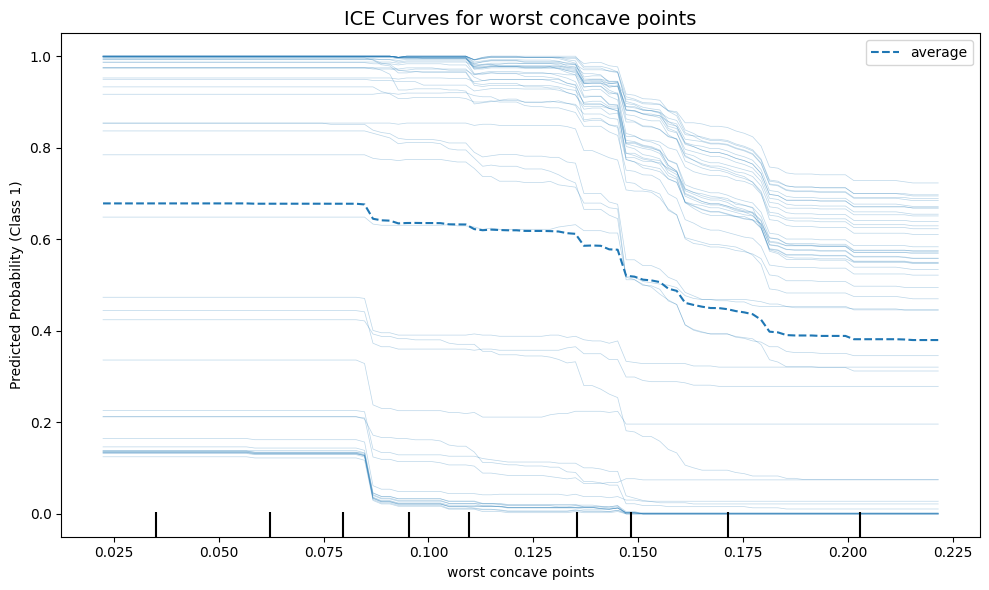

In [20]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)    ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

most_important_feature = [top3_features[-1]]

fig, ax = plt.subplots(figsize=(10, 6))

display = PartialDependenceDisplay.from_estimator(
    best_rf, 
    X_test, 
    features=most_important_feature, 
    kind='both',
    subsample=50,
    ax=ax
)

plt.title(f"ICE Curves for {most_important_feature[0]}", fontsize=14)
plt.xlabel(most_important_feature[0])
plt.ylabel("Predicted Probability (Class 1)")
plt.tight_layout()
plt.show()

Эффект признака однороден (линии параллельны), но исходная вероятность для разных пациентов сильно различается из-за других факторов.

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [ ]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝
explainer = shap.TreeExplainer(best_rf)

raw_shap_values = explainer.shap_values(X_test)

print(f"Тип raw_shap_values: {type(raw_shap_values)}")
print(f"Форма raw_shap_values: {np.array(raw_shap_values).shape}")

if isinstance(raw_shap_values, list):
    print("Это список. Берем элемент с индексом 1 (для класса 1).")
    shap_vals_class1 = raw_shap_values[1]
elif len(np.array(raw_shap_values).shape) == 3:
    print("Это 3D массив. Берем срез [:, :, 1] (для класса 1).")
    shap_vals_class1 = raw_shap_values[:, :, 1]
else:
    print("Это 2D массив. Используем как есть.")
    shap_vals_class1 = raw_shap_values

print(f"Итоговая форма shap_vals_class1: {shap_vals_class1.shape}")

Тип raw_shap_values: <class 'numpy.ndarray'>
Форма raw_shap_values: (114, 30, 2)
Это 3D массив. Берем срез [:, :, 1] (для класса 1).
Итоговая форма shap_vals_class1: (114, 30)


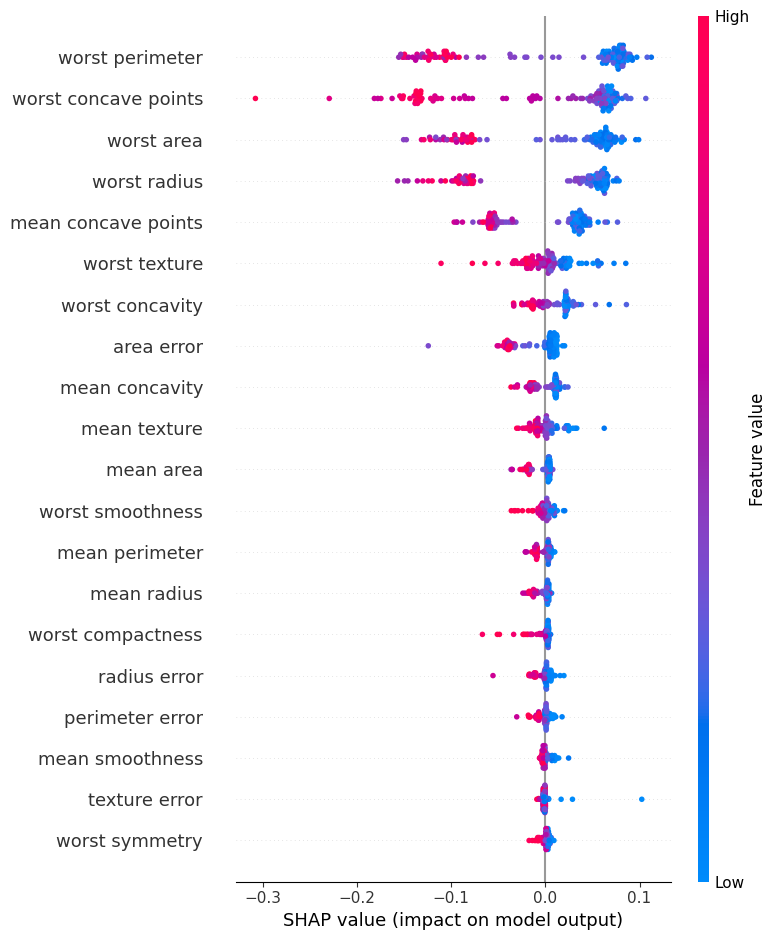

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝
shap.summary_plot(shap_vals_class1, X_test.values, feature_names=X_test.columns.tolist())


Сходство: И там, и там в топе находятся признаки группы concave points и area/perimeter.
Различие: В PI самым важным был worst concave points, а в SHAP на первом месте worst perimeter.
PI может занижать важность коррелированных признаков. Признаки perimeter, area и radius сильно коррелируют друг с другом.

Анализ ошибки:
Индекс: 3
Истинный класс: 1
Предсказанный класс: 0


<Figure size 1500x400 with 0 Axes>

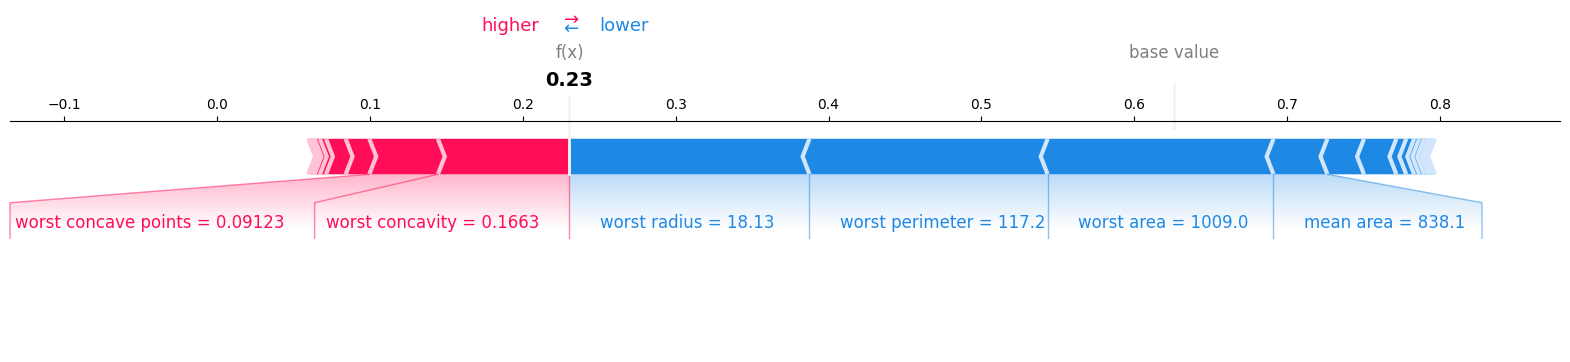

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝
import numpy as np
import shap
import matplotlib.pyplot as plt

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

if len(errors) > 0:
    error_idx = errors[0] 
    
    print(f"Анализ ошибки:")
    print(f"Индекс: {error_idx}")
    print(f"Истинный класс: {y_test.iloc[error_idx]}")
    print(f"Предсказанный класс: {y_pred_test[error_idx]}")
    
    if isinstance(explainer.expected_value, float):
        base_val = explainer.expected_value
    else:
        base_val = explainer.expected_value[1] 

    if hasattr(shap_vals_class1, 'values'):
        single_sv = shap_vals_class1.values[error_idx]
    else:
        single_sv = shap_vals_class1[error_idx]
        
    single_sv = np.array(single_sv).flatten()
    one_sample = X_test.iloc[error_idx].values 
    
    try:
        fig = plt.figure(figsize=(15, 4))
        shap.force_plot(
            base_val, 
            single_sv, 
            one_sample, 
            feature_names=X_test.columns.tolist(),
            matplotlib=True
        )
    except Exception as e:
        print(f"Ошибка с matplotlib=True: {e}")
        print("Попробуем альтернативный вариант...")
        
        explanation = shap.Explanation(
            values=single_sv,
            base_values=base_val,
            data=one_sample,
            feature_names=X_test.columns.tolist()
        )
        shap.plots.waterfall(explanation, max_display=10)
        
else:
    print("Ошибок на тесте не найдено!")

Виноваты признаки размера: worst radius, worst perimeter и worst area.
Форма клетки была хорошей, её размер оказался аномально большим для доброкачественной опухоли. Модель перетянула предсказание в сторону злокачественного класса (0), совершив ошибку, именно из-за большого размера опухоли.

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [ ]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())


F1 Score модели с утечкой: 1.0000
F1 Score обычной модели (RF Random Search): 0.9526
Разница: 0.0474


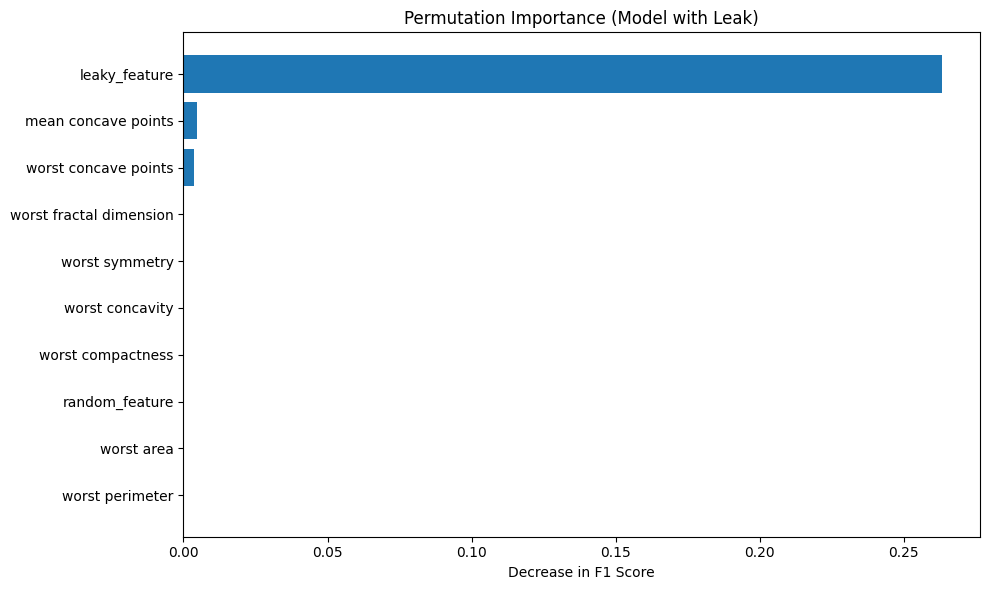

Это 3D массив. Берем срез [:, :, 1] (для класса 1).
Итоговая форма shap_vals_class1: (114, 32)


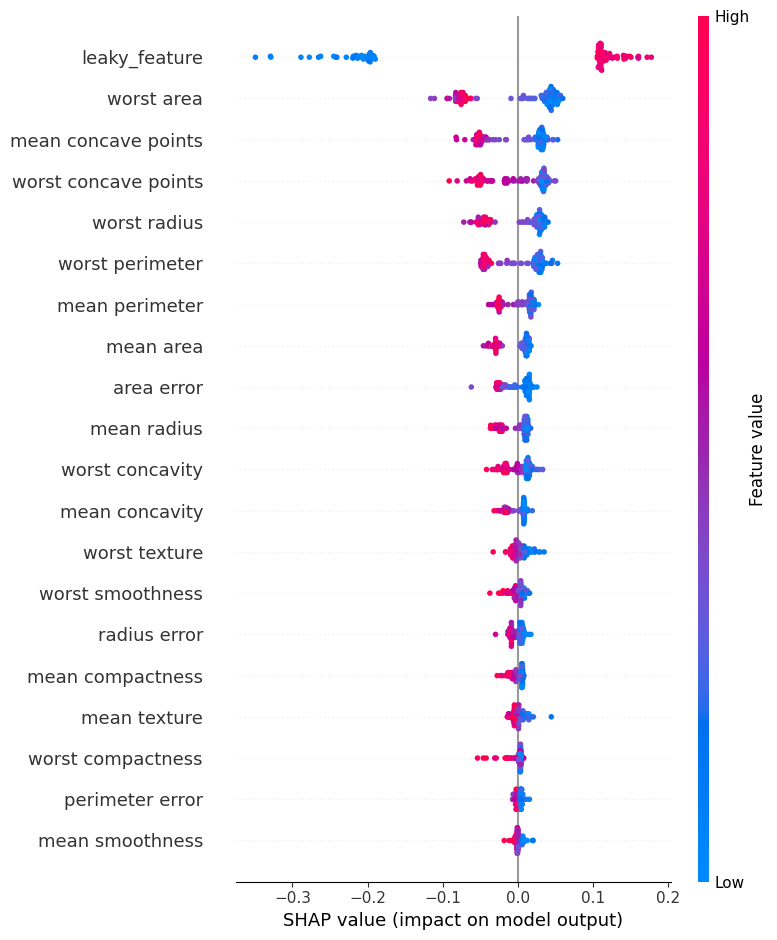

In [54]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

if 'X_train_ext' not in locals():
    np.random.seed(42)
    X_train_ext = X_train.copy()
    X_test_ext = X_test.copy()
    X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
    X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))
    X_train_ext['random_feature'] = np.random.randn(len(y_train))
    X_test_ext['random_feature'] = np.random.randn(len(y_test))

rf_leak = RandomForestClassifier(random_state=42, n_estimators=100)
rf_leak.fit(X_train_ext, y_train)

y_pred_leak = rf_leak.predict(X_test_ext)
f1_leak = f1_score(y_test, y_pred_leak, average='macro')

print(f"\nF1 Score модели с утечкой: {f1_leak:.4f}")
print(f"F1 Score обычной модели (RF Random Search): {rf_test_f1:.4f}")
print(f"Разница: {f1_leak - rf_test_f1:.4f}")

pi_leak = permutation_importance(
    rf_leak, 
    X_test_ext, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='f1_macro'
)

sorted_idx_pi_leak = pi_leak.importances_mean.argsort()
top_idx_pi = sorted_idx_pi_leak[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_idx_pi)), pi_leak.importances_mean[top_idx_pi])
plt.yticks(range(len(top_idx_pi)), X_test_ext.columns[top_idx_pi])
plt.title("Permutation Importance (Model with Leak)")
plt.xlabel("Decrease in F1 Score")
plt.tight_layout()
plt.show()

explainer_leak = shap.TreeExplainer(rf_leak)
shap_values_leak = explainer_leak.shap_values(X_test_ext)

if isinstance(shap_values_leak, list):
    print("Это список. Берем элемент с индексом 1 (для класса 1).")
    shap_vals_leak_class1 = shap_values_leak[1]
elif len(np.array(shap_values_leak).shape) == 3:
    print("Это 3D массив. Берем срез [:, :, 1] (для класса 1).")
    shap_vals_leak_class1 = shap_values_leak[:, :, 1]
else:
    print("Это 2D массив. Используем как есть.")
    shap_vals_leak_class1 = shap_values_leak

print(f"Итоговая форма shap_vals_class1: {shap_vals_leak_class1.shape}")

shap.summary_plot(shap_vals_leak_class1, X_test_ext.values, feature_names=X_test_ext.columns.tolist())

PI измеряет падение метрики (F1-score) при случайном перемешивании значений признака. Поскольку leaky_feature почти идеально коррелирует с таргетом (y), модель научилась использовать его как "ключ" к правильному ответу. Метрика на тесте выросла потому что модель просто запоминает: если leaky_feature высокий, то это класс 1; если низкий — то класс 0.
Красные точки (высокие значения leaky_feature) находятся справа от нуля (положительный SHAP value). Это значит, что высокое значение признака толкает предсказание в сторону класса 1. Синие точки (низкие значения leaky_feature) находятся слева от нуля (отрицательный SHAP value). Это значит, что низкое значение признака толкает предсказание в сторону класса 0. Такая четкая линейная зависимость без разброса говорит о том, что признак является почти идеальным предиктором таргета.
Если добавить новый признак в модель, а его важность во всех методах интерпретации равна нулю — это шум.

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

results_summary = {
    "Метод": [
        "SVM Baseline",
        "SVM Grid Search",
        "RF Baseline",
        "RF Random Search"
    ],
    "CV F1 (mean ± std)": [
        "0.9694 ± 0.0193", 
        "0.9786 ± 0.0175", 
        "0.9504 ± 0.0255",
        "0.9576 ± 0"       
    ],
    "Test F1": [
        "N/A",             
        "0.9812",          
        "N/A",
        "0.9526"           
    ],
    "Выводы": [
        "Хороший старт, стабильно.",
        "Тюнинг дал прирост ~+0.9% по CV. Лучшая модель.",
        "Стабильно, но слабее SVM.",
        "Тюнинг дал небольшой прирост ~+0.7%. Стабильность высокая."
    ]
}

df_summary = pd.DataFrame(results_summary)
# ответ на вопрос один сразу в выводе
print(df_summary.to_string(index=False))

           Метод CV F1 (mean ± std) Test F1                                                     Выводы
    SVM Baseline    0.9694 ± 0.0193     N/A                                  Хороший старт, стабильно.
 SVM Grid Search    0.9786 ± 0.0175  0.9812            Тюнинг дал прирост ~+0.9% по CV. Лучшая модель.
     RF Baseline    0.9504 ± 0.0255     N/A                                  Стабильно, но слабее SVM.
RF Random Search         0.9576 ± 0  0.9526 Тюнинг дал небольшой прирост ~+0.7%. Стабильность высокая.


2) В целом, да. Оба метода выделяют одну и ту же группу признаков как наиболее важные: worst concave points, worst area, worst perimeter, mean concave points. Порядок может немного отличаться. Например, в PI самым важным мог быть worst concave points, а в SHAP на первом месте оказался worst perimeter. Почему? Корреляция: признаки размера (area, perimeter, radius) сильно коррелируют друг с другом. PI: если перемешать perimeter, модель может компенсировать это за счет area, поэтому падение метрики будет меньше, а важность — занижена. SHAP: распределяет вклад между коррелированными признаками более справедливо (на основе теории игр), но всё равно может отдать приоритет одному из них в зависимости от структуры деревьев.
3) Если применить StandardScaler.fit_transform() ко всему X_train до начала кросс-валидации. При разбиении на фолды, статистики нормировки (среднее и стандартное отклонение) вычислялись бы с учетом данных из валидационного фолда. Модель знала бы о распределении валидационных данных еще до обучения. Это привело бы к завышенной оценке качества на кросс-валидации. На реальных новых данных модель работала бы хуже, чем ожидалось, потому что там она не видит "будущего".
4) PI использовал бы на этапе исследования данных (EDA) и первичного отбора признаков чтобы быстро понять, какие признаки реально полезны для модели на тестовых данных. Если у признака важность около нуля или отрицательная — удалить, чтобы упростить и ускорить модель. Shap использовал бы когда нужно глубокое понимание модели или объяснение конкретных решений (например, в медицине, кредитовании, юриспруденции).


## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

Запускаем Optuna...
Лучший результат Optuna (CV F1): 0.9577
Лучшие параметры: {'n_estimators': 187, 'max_depth': 8, 'min_samples_split': 3, 'max_features': 'sqrt'}


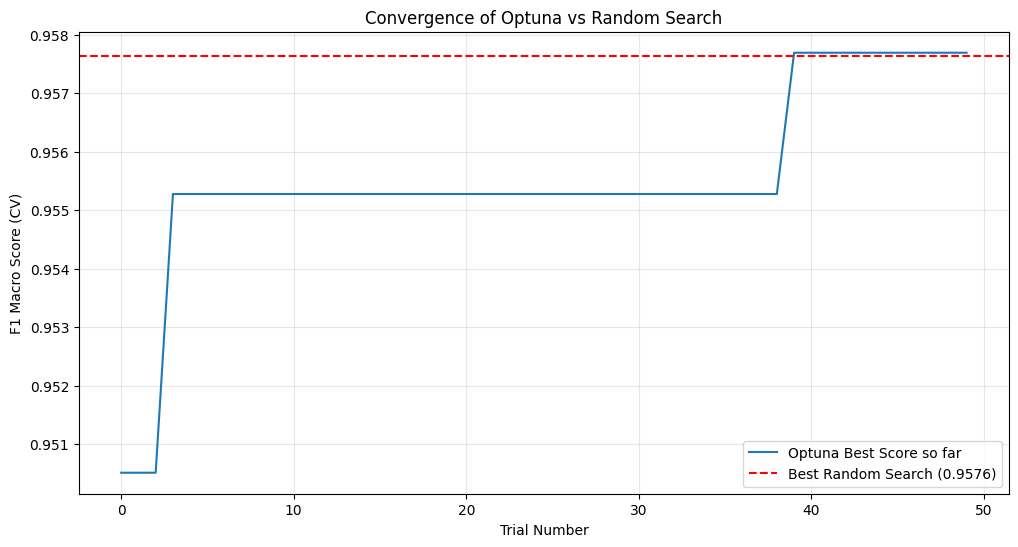

In [ ]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    
    max_depth = trial.suggest_categorical('max_depth', [None] + list(range(2, 21)))
    
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    score = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1).mean()
    
    return score

print("Запускаем Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=False)

print(f"Лучший результат Optuna (CV F1): {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

best_values = [t.value for t in study.trials]
cumulative_best = []
current_best = -float('inf')
for val in best_values:
    if val > current_best:
        current_best = val
    cumulative_best.append(current_best)

plt.figure(figsize=(12, 6))
plt.plot(cumulative_best, label='Optuna Best Score so far')
plt.axhline(y=rf_random_search.best_score_, color='r', linestyle='--', label=f'Best Random Search ({rf_random_search.best_score_:.4f})')
plt.title("Convergence of Optuna vs Random Search")
plt.xlabel("Trial Number")
plt.ylabel("F1 Macro Score (CV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Random Search просто тыкает наугад. Если он попал в хорошее место на 10-й итерации, на 11-й он может уйти в совершенно другое, плохое место. Optuna же "помнит" историю. Видя, что определенные диапазоны параметров дают хороший результат, он фокусируется на них, уточняя поиск.
Каждая вертикальная часть ступеньки — это момент, когда Optuna нашел новый рекорд. Горизонтальные части — периоды, когда алгоритм искал, но не находил улучшений. Чем длиннее горизонтальный участок в конце, тем вероятнее, что алгоритм сошелся к глобальному (или очень хорошему локальному) оптимуму.
На графике видно, что Optuna потребовалось около 40 итераций, чтобы гарантированно превзойти лучший результат Random Search. При этом, если бы мы остановились на 20-й итерации, Random Search выиграл бы. Но поскольку Optuna продолжает учиться, на дистанции он выходит вперед.